# Import thư viện

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# 1. Dataset Overview

In [2]:
df = pd.read_csv("../data/data.csv", encoding="ISO-8859-1")

In [3]:
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

In [4]:
df.head(5)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [5]:
df.tail(5)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France
541908,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,2011-12-09 12:50:00,4.95,12680.0,France


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


In [7]:
df.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID
count,541909.000000,541909,541909.000000,406829.000000
mean,9.552250,2011-07-04 13:34:57.156386048,4.611114,15287.690570
min,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000
25%,1.000000,2011-03-28 11:34:00,1.250000,13953.000000
50%,3.000000,2011-07-19 17:17:00,2.080000,15152.000000
75%,10.000000,2011-10-19 11:27:00,4.130000,16791.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000
std,218.081158,NaN,96.759853,1713.600303


In [8]:
df.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='object')

In [9]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [10]:
df.duplicated().sum()

np.int64(5268)

# 2. Data Cleaning

#### remove duplicates

In [11]:
df = df.drop_duplicates()

In [12]:
df.duplicated().sum()

np.int64(0)

In [13]:
df.duplicated().any()

np.False_

#### drop row missing values

In [14]:
df = df.dropna(subset=["CustomerID"])

In [15]:
df.isnull().sum()

InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64

In [16]:
df["CustomerID"] = df["CustomerID"].astype(int)

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 401604 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    401604 non-null  object        
 1   StockCode    401604 non-null  object        
 2   Description  401604 non-null  object        
 3   Quantity     401604 non-null  int64         
 4   InvoiceDate  401604 non-null  datetime64[ns]
 5   UnitPrice    401604 non-null  float64       
 6   CustomerID   401604 non-null  int64         
 7   Country      401604 non-null  object        
dtypes: datetime64[ns](1), float64(1), int64(2), object(4)
memory usage: 27.6+ MB


# 3. Feature Engineering

In [18]:
# Vì dataset ban đầu không có cột doanh thu, mình tự tạo ra để phân tích.
df["Revenue"] = df["Quantity"] * df["UnitPrice"]

In [19]:
df["Month"] = df["InvoiceDate"].dt.to_period("M")

In [20]:
df["Year"] = df["InvoiceDate"].dt.year

In [21]:
df["DayOfWeek"] = df["InvoiceDate"].dt.day_name()

# 4. Exploratory Data Analysis (EDA)

In [22]:
# Tổng doanh thu
df["Revenue"].sum()

np.float64(8278519.4240000015)

In [23]:
# Tổng số khách hàng
df["CustomerID"].nunique()

4372

In [24]:
# Tổng số giao dịch
df["InvoiceNo"].nunique()

22190

In [25]:
# Quốc gia mua hàng nhiều nhất
df["Country"].value_counts().head(10)

Country
United Kingdom    356728
Germany             9480
France              8475
EIRE                7475
Spain               2528
Netherlands         2371
Belgium             2069
Switzerland         1877
Portugal            1471
Australia           1258
Name: count, dtype: int64

In [26]:
# Top sản phẩm bán nhiều nhất
df["Description"].value_counts().head(10)

Description
WHITE HANGING HEART T-LIGHT HOLDER    2058
REGENCY CAKESTAND 3 TIER              1894
JUMBO BAG RED RETROSPOT               1659
PARTY BUNTING                         1409
ASSORTED COLOUR BIRD ORNAMENT         1405
LUNCH BAG RED RETROSPOT               1345
SET OF 3 CAKE TINS PANTRY DESIGN      1224
POSTAGE                               1196
LUNCH BAG  BLACK SKULL.               1099
PACK OF 72 RETROSPOT CAKE CASES       1062
Name: count, dtype: int64

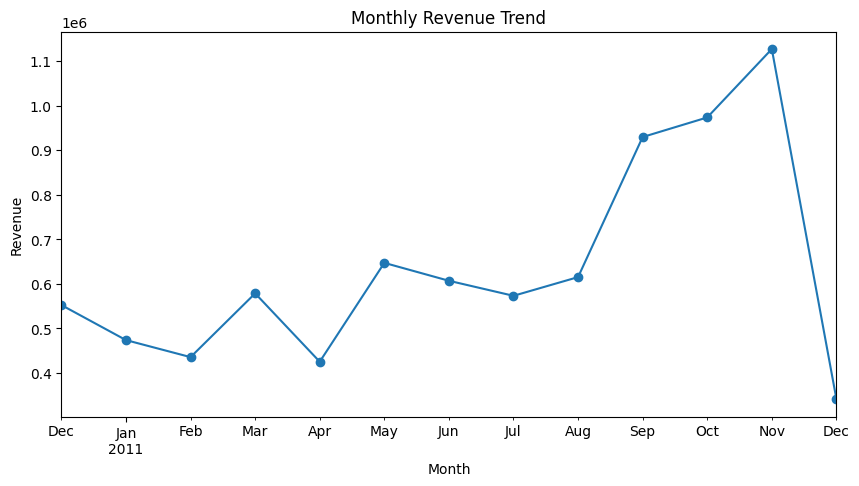

In [27]:
# Doanh thu (Revenue) theo tháng
monthly_revenue = df.groupby("Month")["Revenue"].sum() # tổng doanh thu từng tháng

plt.figure(figsize=(10,5))

monthly_revenue.plot(marker="o")

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")

plt.savefig("../images/revenue_trend.png", dpi=300, bbox_inches="tight")
plt.show()

Doanh thu có xu hướng tăng mạnh từ tháng 9 đến tháng 11 và đạt đỉnh vào tháng 11. Điều này cho thấy nhu cầu mua sắm tăng cao vào giai đoạn cuối năm, có thể liên quan đến các dịp lễ và mùa mua sắm cuối năm.

Ngoài ra, doanh thu tháng 12 giảm mạnh bất thường. Nguyên nhân có thể do dữ liệu của tháng 12 chưa được ghi nhận đầy đủ trong dataset.

In [28]:
country_revenue = (
    df.groupby("Country")["Revenue"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

country_revenue

Country
United Kingdom    6747156.154
Netherlands        284661.540
EIRE               250001.780
Germany            221509.470
France             196626.050
Australia          137009.770
Switzerland         55739.400
Spain               54756.030
Belgium             40910.960
Sweden              36585.410
Name: Revenue, dtype: float64

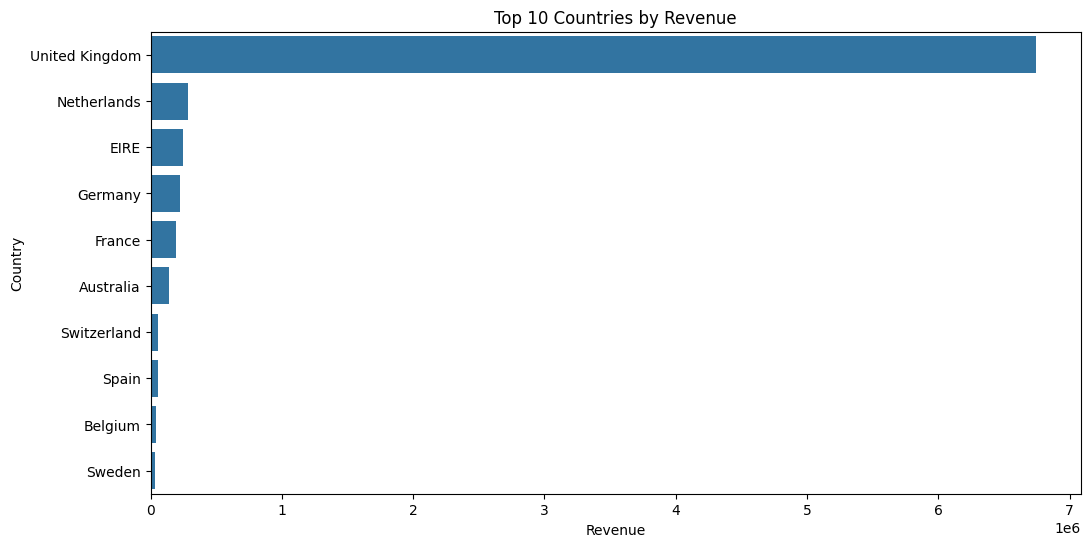

In [29]:
plt.figure(figsize=(12,6))

sns.barplot(
    x=country_revenue.values,
    y=country_revenue.index
)

plt.title("Top 10 Countries by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Country")

plt.savefig("../images/top_countries.png", dpi=300, bbox_inches="tight")

plt.show()

United Kingdom là thị trường tạo ra doanh thu lớn nhất và vượt xa các quốc gia còn lại. Điều này cho thấy phần lớn hoạt động kinh doanh và khách hàng của doanh nghiệp tập trung tại thị trường UK.

Trong khi đó, các quốc gia như Netherlands, Germany và France đóng góp doanh thu thấp hơn đáng kể. Điều này cho thấy doanh nghiệp vẫn còn nhiều tiềm năng mở rộng doanh thu tại các thị trường quốc tế ngoài UK.

In [30]:
top_products = (
    df.groupby("Description")["Revenue"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_products

Description
REGENCY CAKESTAND 3 TIER              132567.70
WHITE HANGING HEART T-LIGHT HOLDER     93767.80
JUMBO BAG RED RETROSPOT                83056.52
PARTY BUNTING                          67628.43
POSTAGE                                66710.24
ASSORTED COLOUR BIRD ORNAMENT          56331.91
RABBIT NIGHT LIGHT                     51042.84
CHILLI LIGHTS                          45915.41
PAPER CHAIN KIT 50'S CHRISTMAS         41423.78
PICNIC BASKET WICKER 60 PIECES         39619.50
Name: Revenue, dtype: float64

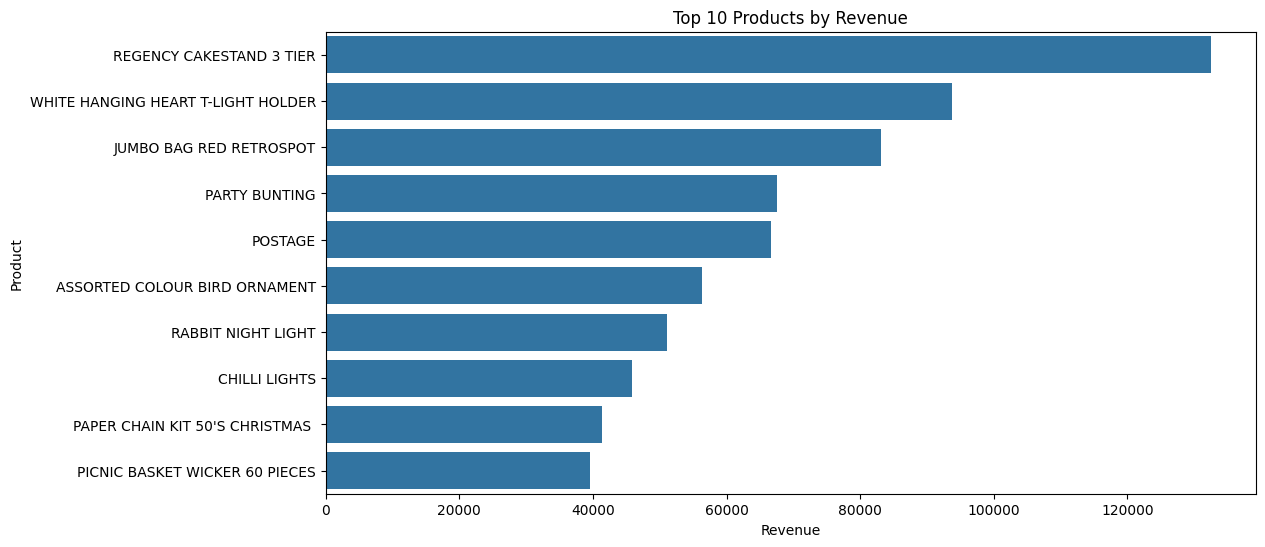

In [31]:
plt.figure(figsize=(12,6))

sns.barplot(
    x=top_products.values,
    y=top_products.index
)

plt.title("Top 10 Products by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Product")

plt.savefig("../images/top_products.png", dpi=300, bbox_inches="tight")

plt.show()

Một số sản phẩm tạo ra doanh thu vượt trội so với phần còn lại, trong đó “REGENCY CAKESTAND 3 TIER” là sản phẩm có doanh thu cao nhất.

Điều này cho thấy doanh thu của doanh nghiệp đang tập trung vào một nhóm sản phẩm chủ lực, đóng vai trò quan trọng trong việc thúc đẩy tổng doanh thu.

# 5. Customer Behavior Analysis

In [32]:
top_customers = (
    df.groupby("CustomerID")["Revenue"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_customers

CustomerID
14646    279489.02
18102    256438.49
17450    187322.17
14911    132458.73
12415    123725.45
14156    113214.59
17511     88125.38
16684     65892.08
13694     62690.54
15311     59284.19
Name: Revenue, dtype: float64

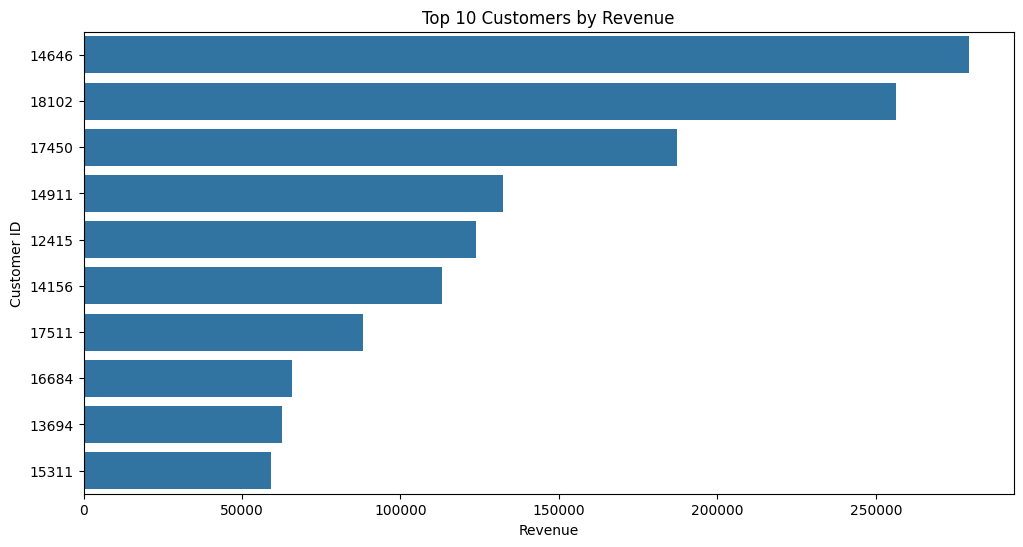

In [33]:
plt.figure(figsize=(12,6))

sns.barplot(
    x=top_customers.values,
    y=top_customers.index.astype(str)
)

plt.title("Top 10 Customers by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Customer ID")

plt.show()

Một nhóm nhỏ khách hàng tạo ra phần lớn doanh thu của doanh nghiệp. Điều này cho thấy tệp khách hàng VIP đóng vai trò quan trọng trong hoạt động kinh doanh.

In [34]:
# Tính số lần mua của mỗi khách
purchase_frequency = (
    df.groupby("CustomerID")["InvoiceNo"]
    .nunique()
)

In [35]:
purchase_frequency.describe()

count    4372.000000
mean        5.075480
std         9.338754
min         1.000000
25%         1.000000
50%         3.000000
75%         5.000000
max       248.000000
Name: InvoiceNo, dtype: float64

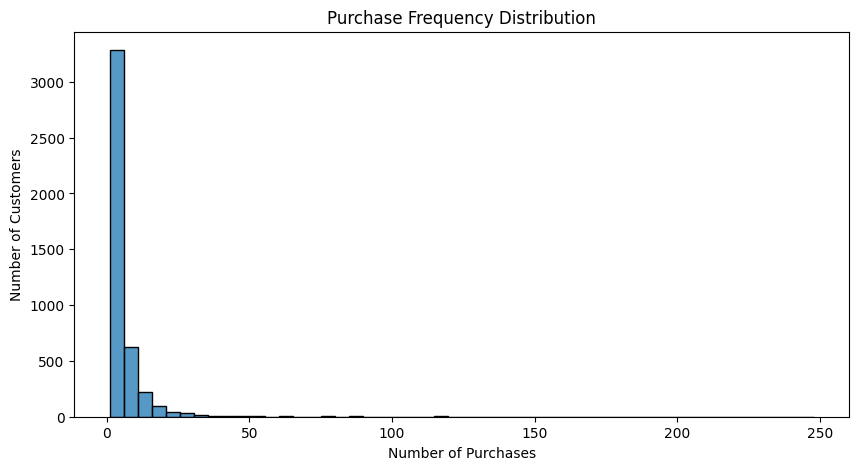

In [36]:
plt.figure(figsize=(10,5))

sns.histplot(
    purchase_frequency,
    bins=50
)

plt.title("Purchase Frequency Distribution")
plt.xlabel("Number of Purchases")
plt.ylabel("Number of Customers")

plt.show()

Phân bố tần suất mua hàng bị lệch phải, cho thấy đa số khách hàng có số lần mua thấp, trong khi chỉ một nhóm nhỏ khách hàng trung thành tạo ra nhiều giao dịch hơn.

### Average Order Value (AOV) Giá trị trung bình mỗi đơn

In [37]:
total_revenue = df["Revenue"].sum()

total_revenue

np.float64(8278519.4240000015)

In [38]:
total_orders = df["InvoiceNo"].nunique()

total_orders

22190

In [39]:
aov = total_revenue / total_orders

aov

np.float64(373.0743318611988)

Giá trị trung bình mỗi đơn hàng (AOV) đạt khoảng 373, cho thấy khách hàng có xu hướng chi tiêu tương đối cao trong mỗi giao dịch.

# 6. Cohort & Retention Analysis

Khách hàng có quay lại mua hàng ở các tháng sau không?

In [40]:
# Tạo cột PurchaseMonth
df["PurchaseMonth"] = df["InvoiceDate"].dt.to_period("M")

In [41]:
# Tìm tháng mua đầu tiên của mỗi khách
# CohortMonth = tháng đầu tiên khách mua hàng.
df["CohortMonth"] = (
    df.groupby("CustomerID")["PurchaseMonth"]
    .transform("min")
)

In [42]:
# Tạo Cohort Index
# CohortIndex = tháng thứ mấy kể từ tháng mua đầu tiên.
df["CohortIndex"] = (
    (df["PurchaseMonth"].dt.year - df["CohortMonth"].dt.year) * 12
    + (df["PurchaseMonth"].dt.month - df["CohortMonth"].dt.month)
    + 1
)

In [43]:
# Tạo retention table
cohort_data = (
    df.groupby(["CohortMonth", "CohortIndex"])["CustomerID"]
    .nunique()
    .reset_index()
)

cohort_data.head()

,CohortMonth,CohortIndex,CustomerID
0,2010-12,1,948
1,2010-12,2,362
2,2010-12,3,317
3,2010-12,4,367
4,2010-12,5,341


In [44]:
# Pivot table
cohort_table = cohort_data.pivot(
    index="CohortMonth",
    columns="CohortIndex",
    values="CustomerID"
)

cohort_table

CohortIndex,1,2,3,4,5,6,7,8,9,10,11,12,13
CohortMonth,,,,,,,,,,,,,
2010-12,948.0,362.0,317.0,367.0,341.0,376.0,360.0,336.0,336.0,374.0,354.0,474.0,260.0
2011-01,421.0,101.0,119.0,102.0,138.0,126.0,110.0,108.0,131.0,146.0,155.0,63.0,NaN
2011-02,380.0,94.0,73.0,106.0,102.0,94.0,97.0,107.0,98.0,119.0,35.0,NaN,NaN
2011-03,440.0,84.0,112.0,96.0,102.0,78.0,116.0,105.0,127.0,39.0,NaN,NaN,NaN
2011-04,299.0,68.0,66.0,63.0,62.0,71.0,69.0,78.0,25.0,NaN,NaN,NaN,NaN
2011-05,279.0,66.0,48.0,48.0,60.0,68.0,74.0,29.0,NaN,NaN,NaN,NaN,NaN
2011-06,235.0,49.0,44.0,64.0,58.0,79.0,24.0,NaN,NaN,NaN,NaN,NaN,NaN
2011-07,191.0,40.0,39.0,44.0,52.0,22.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2011-08,167.0,42.0,42.0,42.0,23.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [45]:
# Tính retention rate
retention_table = cohort_table.divide(
    cohort_table.iloc[:, 0],
    axis=0
)

retention_table

CohortIndex,1,2,3,4,5,6,7,8,9,10,11,12,13
CohortMonth,,,,,,,,,,,,,
2010-12,1.0,0.381857,0.334388,0.387131,0.359705,0.396624,0.379747,0.354430,0.354430,0.394515,0.373418,0.500000,0.274262
2011-01,1.0,0.239905,0.282660,0.242280,0.327791,0.299287,0.261283,0.256532,0.311164,0.346793,0.368171,0.149644,NaN
2011-02,1.0,0.247368,0.192105,0.278947,0.268421,0.247368,0.255263,0.281579,0.257895,0.313158,0.092105,NaN,NaN
2011-03,1.0,0.190909,0.254545,0.218182,0.231818,0.177273,0.263636,0.238636,0.288636,0.088636,NaN,NaN,NaN
2011-04,1.0,0.227425,0.220736,0.210702,0.207358,0.237458,0.230769,0.260870,0.083612,NaN,NaN,NaN,NaN
2011-05,1.0,0.236559,0.172043,0.172043,0.215054,0.243728,0.265233,0.103943,NaN,NaN,NaN,NaN,NaN
2011-06,1.0,0.208511,0.187234,0.272340,0.246809,0.336170,0.102128,NaN,NaN,NaN,NaN,NaN,NaN
2011-07,1.0,0.209424,0.204188,0.230366,0.272251,0.115183,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2011-08,1.0,0.251497,0.251497,0.251497,0.137725,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Bảng cohort cho thấy tỷ lệ khách hàng quay lại giảm rõ rệt sau tháng mua đầu tiên. Hầu hết các cohort chỉ giữ lại khoảng 20%–35% khách hàng ở tháng thứ hai, cho thấy doanh nghiệp cần tập trung vào các hoạt động chăm sóc và giữ chân khách hàng ngay sau lần mua đầu tiên.

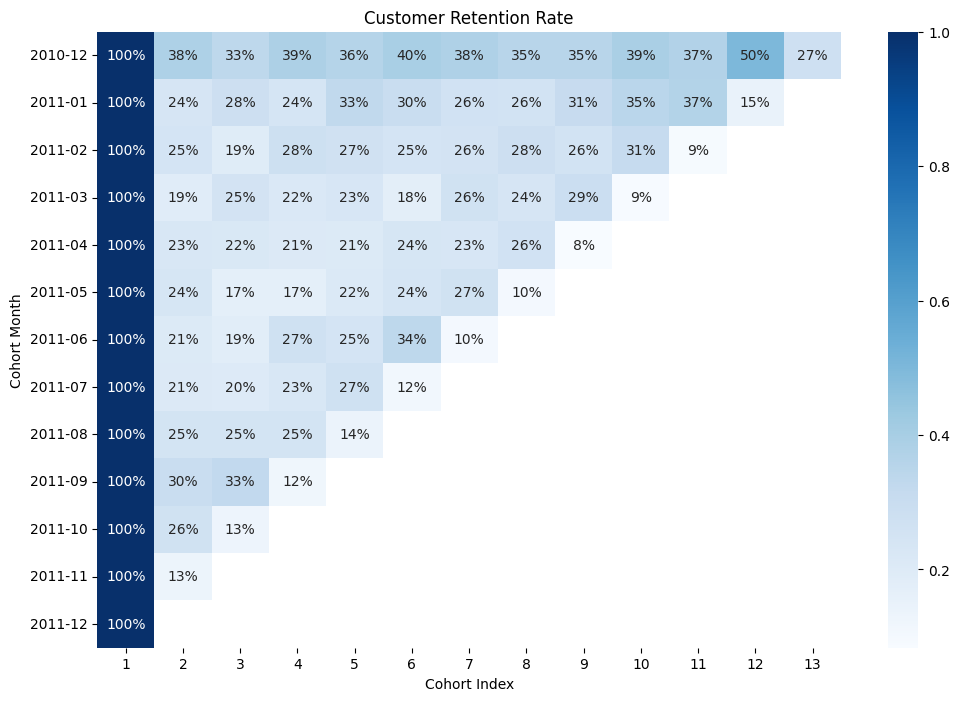

In [46]:
# Vẽ heatmap
plt.figure(figsize=(12,8))

sns.heatmap(
    retention_table,
    annot=True,
    fmt=".0%",
    cmap="Blues"
)

plt.title("Customer Retention Rate")
plt.xlabel("Cohort Index")
plt.ylabel("Cohort Month")

plt.savefig("../images/retention_heatmap.png", dpi=300, bbox_inches="tight")

plt.show()

Một số cohort đầu năm và cuối năm có retention cao hơn các cohort còn lại, cho thấy yếu tố mùa vụ và các chiến dịch bán hàng có thể ảnh hưởng đến hành vi quay lại mua hàng của khách hàng.

# 7. RFM Customer Segmentation

RFM là gì?

Recency:	khách mua gần đây không

Frequency:	mua bao nhiêu lần

Monetary: 	chi bao nhiêu tiền

In [47]:
snapshot_date = df["InvoiceDate"].max() + pd.Timedelta(days=1) # giả sử ngày cuối dataset

snapshot_date

Timestamp('2011-12-10 12:50:00')

In [48]:
# Tạo bảng RFM
rfm = df.groupby("CustomerID").agg({
    "InvoiceDate": lambda x: (snapshot_date - x.max()).days,
    "InvoiceNo": "nunique",
    "Revenue": "sum"
})

rfm.columns = ["Recency", "Frequency", "Monetary"]

rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346,326,2,0.00
12347,2,7,4310.00
12348,75,4,1797.24
12349,19,1,1757.55
12350,310,1,334.40


In [49]:
# Chia score
# 
rfm["R_Score"] = pd.qcut(rfm["Recency"], 4, labels=[4,3,2,1]) # chia dữ liệu thành 4 nhóm mua gần nhất là mức 1 lâu nhất là mức 4
rfm["F_Score"] = pd.qcut(rfm["Frequency"].rank(method="first"), 4, labels=[1,2,3,4])# Vì nhiều khách có Frequency giống nhau dễ lỗi qcut nên dùng rank
rfm["M_Score"] = pd.qcut(rfm["Monetary"], 4, labels=[1,2,3,4])

In [50]:
# Tạo RFM Score
rfm["RFM_Score"] = (
    rfm["R_Score"].astype(str) +
    rfm["F_Score"].astype(str) +
    rfm["M_Score"].astype(str)
)

rfm.head()

,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score
CustomerID,,,,,,,
12346,326,2,0.00,1,2,1,121
12347,2,7,4310.00,4,4,4,444
12348,75,4,1797.24,2,3,4,234
12349,19,1,1757.55,3,1,4,314
12350,310,1,334.40,1,1,2,112


In [51]:
# Segment khách hàng
def customer_segment(row):
    if row["RFM_Score"] == "444":
        return "VIP Customers"
    elif row["R_Score"] >= 3 and row["F_Score"] >= 3:
        return "Loyal Customers"
    elif row["R_Score"] <= 2 and row["F_Score"] >= 3:
        return "At Risk Customers"
    else:
        return "Regular Customers"

rfm["Segment"] = rfm.apply(customer_segment, axis=1)

In [54]:
df = df.merge(
    rfm[["Segment"]],
    left_on="CustomerID",
    right_index=True,
    how="left"
)

df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue,Month,Year,DayOfWeek,PurchaseMonth,CohortMonth,CohortIndex,Segment
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30,2010-12,2010,Wednesday,2010-12,2010-12,1,At Risk Customers
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,2010-12,2010,Wednesday,2010-12,2010-12,1,At Risk Customers
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00,2010-12,2010,Wednesday,2010-12,2010-12,1,At Risk Customers
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,2010-12,2010,Wednesday,2010-12,2010-12,1,At Risk Customers
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,2010-12,2010,Wednesday,2010-12,2010-12,1,At Risk Customers


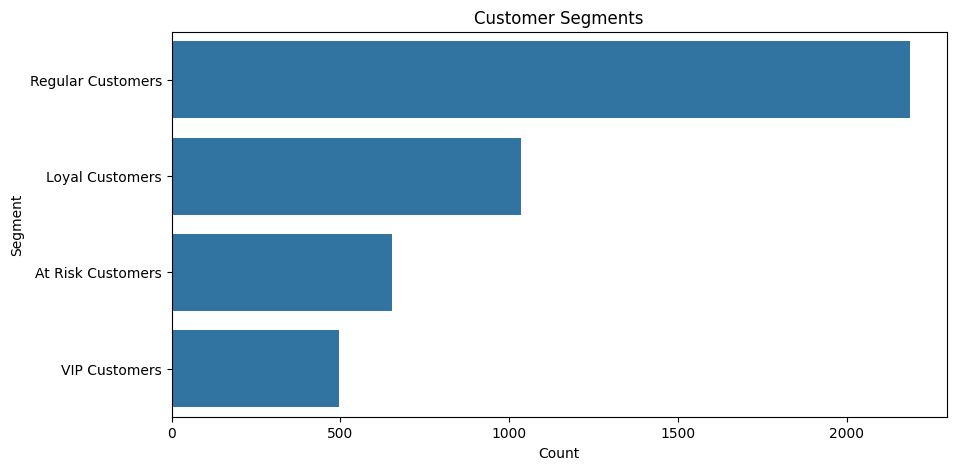

In [52]:
# Visualization
plt.figure(figsize=(10,5))

sns.countplot(
    y=rfm["Segment"],
    order=rfm["Segment"].value_counts().index
)

plt.title("Customer Segments")
plt.xlabel("Count")
plt.ylabel("Segment")

plt.savefig("../images/customer_segments.png", dpi=300, bbox_inches="tight")

plt.show()

Phần lớn khách hàng của doanh nghiệp thuộc nhóm Regular Customers, cho thấy đa số khách hàng chỉ mua với tần suất và giá trị trung bình. Tuy nhiên, doanh nghiệp vẫn sở hữu một nhóm Loyal Customers và VIP Customers tương đối đáng kể — đây là nhóm khách hàng mang lại doanh thu cao và có xu hướng quay lại mua hàng thường xuyên. 

Bên cạnh đó, vẫn tồn tại một nhóm At Risk Customers, tức những khách hàng từng mua nhiều nhưng đã giảm mức độ tương tác trong thời gian gần đây. Điều này cho thấy doanh nghiệp cần triển khai các chiến dịch chăm sóc lại khách hàng cũ như email marketing, voucher ưu đãi hoặc chương trình loyalty để tăng tỷ lệ giữ chân khách hàng.

In [55]:
df.to_csv("cleaned_ecommerce.csv", index=False)